In [99]:
import pandas as pd


df = pd.read_csv("result/res.csv")

df['relative_error_percent'].mean()

np.float64(6.585116279069768)

In [100]:
df

,file_name,type,dimension,total_distance,optimal_distance,relative_error_percent,inference_time
0,E-n101-k14.vrp,E,101,1155.46,1071.0,7.89,362.7785
1,E-n101-k8.vrp,E,101,854.69,817.0,4.61,286.8213
2,E-n13-k4.vrp,E,13,290.00,247.0,17.41,2.3452
3,E-n22-k4.vrp,E,22,375.28,375.0,0.07,7.3419
4,E-n23-k3.vrp,E,23,568.56,569.0,0.08,6.5773
5,E-n30-k3.vrp,E,30,535.80,534.0,0.34,11.5661
6,E-n33-k4.vrp,E,33,837.67,835.0,0.32,17.7476
7,E-n51-k5.vrp,E,51,550.14,521.0,5.59,49.4671
8,E-n76-k10.vrp,E,76,999.98,830.0,20.48,159.2440
9,E-n76-k14.vrp,E,76,1069.87,1021.0,4.79,185.3133


In [101]:
import numpy as np

df2 = df[df['relative_error_percent'] < 200]

total_dist = np.asarray(df2['total_distance'])
optim_dist = np.asarray(df2['optimal_distance'])

mape = np.mean(np.abs((optim_dist - total_dist)/optim_dist))

mape

np.float64(0.06584773930100637)

In [102]:
df[df['relative_error_percent'] < 200]['relative_error_percent'].mean()

np.float64(6.585116279069768)

In [38]:
print(df[df['relative_error_percent'] > 40]['file_name'].to_string(index=False))

 E-n31-k7.vrp
E-n76-k10.vrp
M-n121-k7.vrp
P-n51-k10.vrp


In [61]:
import vrplib

f_n = "E-n31-k7"
f = vrplib.read_instance(f"samples/{f_n}.vrp")

In [62]:
sol = vrplib.read_solution(f"{f_n}.sol")
sol

{'routes': [[30],
  [26, 4, 17, 5, 16],
  [29, 23],
  [21, 11, 13, 9, 28, 15],
  [20, 6, 22, 8, 2, 19],
  [25, 1, 14, 3, 24],
  [10, 18, 12, 7, 27]],
 'cost': 379}

In [63]:
def calc_cost(routes, dist, depot=0):
    total = 0.0

    for route in routes:
        if not route:
            continue

        prev = depot
        for node in route:
            total += dist[prev, node]
            prev = node
        total += dist[prev, depot]

    return total

total_cost = calc_cost(sol["routes"], f['edge_weight'])
print("calculated:", total_cost)
print("claimed   :", sol["cost"])

calculated: 1815.0
claimed   : 379


In [64]:
df['inference_time'].mean()

np.float64(70.58662272727271)

In [66]:
from collections import Counter

Counter(df['type'])

Counter({'P': 24, 'E': 13, 'M': 4, 'F': 3})

Text(0.5, 1.0, 'Увеличение времени вывода из-за повышения размерности.')

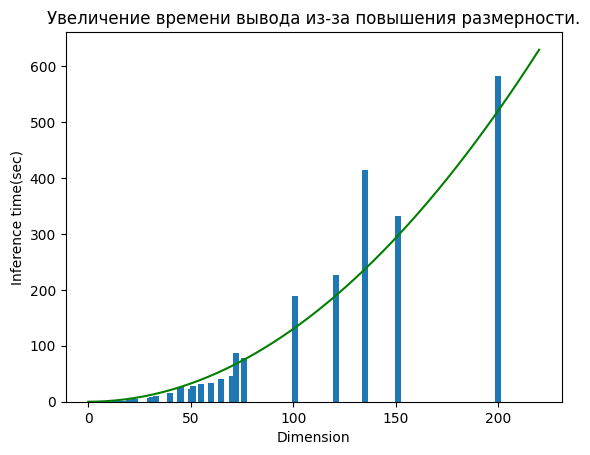

In [98]:
from matplotlib import pyplot as plt

plt.bar(df['dimension'],df['inference_time'], width=3)

x = np.linspace(0,220)
y = 0.013*x**2
plt.plot(x,y, color="g")
plt.xlabel("Dimension")
plt.ylabel("Inference time(sec)")
plt.title("Увеличение времени вывода из-за повышения размерности.")